# 1.3 — Transforming Graphs, at the computer

Do the **pen-and-paper worksheet first**. Here you verify your sketches, catch "opposite day"
red-handed, and normalise your first dataset — the exact move every ML pipeline starts with.

Run each cell with **Shift+Enter**.

In [1]:
# Setup — run this first.
import sys
sys.path.append("../../../tools")

import numpy as np
import matplotlib.pyplot as plt
from plots import plot_functions, axes_through_origin

## 1. Opposite day, caught on camera

Same $+3$, two different doors: added to the **output** ($f(x)+3$) vs stuffed into the
**input slot** ($f(x+3)$). Predict which way each copy of the valley moves, *then* run:

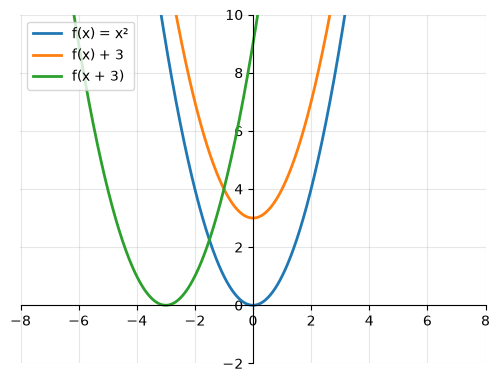

In [2]:
f = lambda x: x**2

plot_functions({
    "f(x) = x²":       f,
    "f(x) + 3":        lambda x: f(x) + 3,      # outside the brackets: intuitive (up)
    "f(x + 3)":        lambda x: f(x + 3),      # inside the brackets: opposite day (LEFT)
}, xlim=(-8, 8), ylim=(-2, 10))
plt.show()

# Why left? f(x+3) at x = -3 computes f(0) — the old vertex output shows up 3 early.

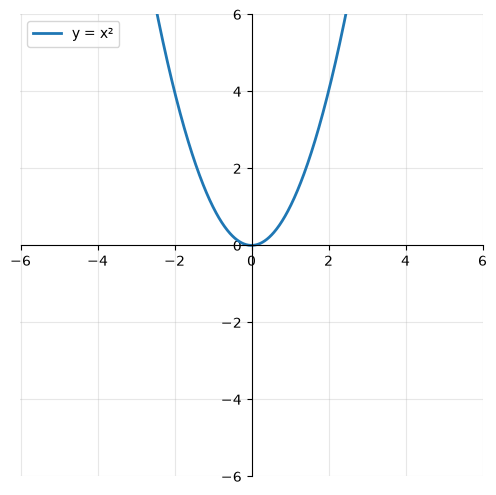

In [3]:
# YOUR TURN — worksheet problem 8 was y = -(x-1)² + 4.
# Your paper sketch said: hill or valley? vertex where?
# Write the machine below and check yourself.

plot_functions({
    "y = x²": lambda x: x**2,
    # "y = -(x-1)² + 4": lambda x: ...,   # <- your machine here
}, xlim=(-6, 6), ylim=(-6, 6))
plt.show()

## 2. Shifts move asymptotes; stretches (from zero) don't

Worksheet problem 12's trap, on screen. Watch the floor of $2^x$:

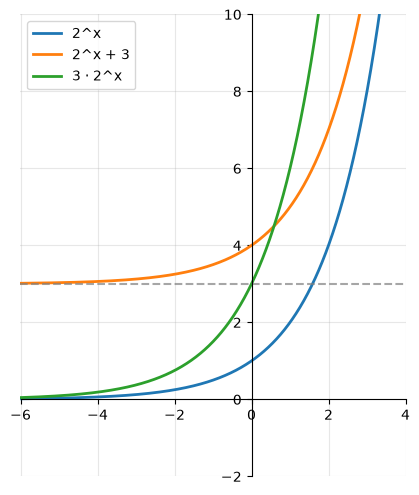

In [4]:
ax = plot_functions({
    "2^x":       lambda x: 2**x,
    "2^x + 3":   lambda x: 2**x + 3,   # lifted — floor and all
    "3 · 2^x":   lambda x: 3 * 2**x,   # stretched — floor stays at 0 (3 × 0 is still 0)
}, xlim=(-6, 4), ylim=(-2, 10))
ax.axhline(3, color="gray", linestyle="--", alpha=0.7)   # new floor for the shifted one
plt.show()

## 3. Normalisation = transformations applied to DATA

The ritual at the start of every ML project: $z = \dfrac{x - \mu}{\sigma}$
(subtract the mean, divide by the spread). That's a **shift** then a **stretch** — the same
moves from Part A, applied to a pile of measurements instead of a curve. Watch a dataset get
dragged to 0 and squashed to standard size:

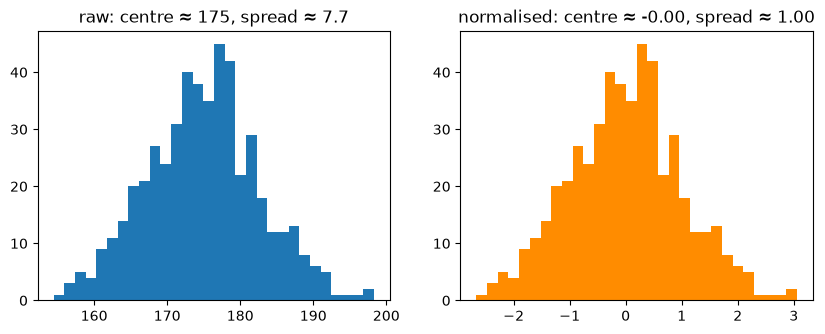

In [5]:
rng = np.random.default_rng(42)
heights = rng.normal(175, 8, size=500)      # fake dataset: 500 heights, centre 175cm, spread 8

z = (heights - heights.mean()) / heights.std()   # shift to 0, stretch to spread 1

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))   # two plots side by side
axes[0].hist(heights, bins=30)
axes[0].set_title(f"raw: centre ≈ {heights.mean():.0f}, spread ≈ {heights.std():.1f}")
axes[1].hist(z, bins=30, color="darkorange")
axes[1].set_title(f"normalised: centre ≈ {z.mean():.2f}, spread ≈ {z.std():.2f}")
plt.show()

# Same shape, new home: centred on 0, spread 1. Networks train FAR better on the orange version —
# and now you know normalisation is just unit 1.3 applied to a dataset.

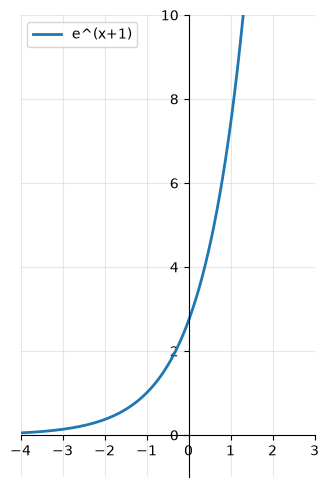

In [6]:
# YOUR TURN — the lesson's deep-end (worksheet 15): e^(x+1) is BOTH 'shift left 1'
# AND 'stretch by e'. If that's true, these two machines are one machine,
# and the plot should show ONE curve, not two.

plot_functions({
    "e^(x+1)":   lambda x: np.exp(x + 1),
    # "e · e^x": lambda x: ...,          # <- write the stretch version (np.e is the number e)
}, xlim=(-4, 3), ylim=(-1, 10))
plt.show()

# Then try the same stunt with x²: plot (x+1)² and see if ANY vertical stretch a·x² matches it.
# (It won't — a stretched valley keeps its vertex at x = 0. Only exponentials have this alibi.)

## The neuron punchline

A neuron computes $w \cdot x + b$ — stretch by the weight, shift by the bias. During training,
the network wiggles millions of these little transformations until the whole composed machine
fits the data. "Learning" is graph transformations, tuned automatically.

---
*Done? Photograph your worksheet into `scans/inbox/`.
Next: 1.4 — composing functions: what "deep" in deep learning literally means.*